In [2]:
from keras.datasets import imdb

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)


In [3]:
train_data[0]
train_labels[0]

np.int64(1)

In [4]:
max([max(sequence) for sequence in train_data] )

9999

In [5]:
word_index = imdb.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_review = ' '.join([reverse_word_index.get(i - 3, '?') for i in train_data[0]])

In [6]:
import numpy as np
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.
    return results

In [7]:
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)


In [8]:
x_train[0]

array([0., 1., 1., ..., 0., 0., 0.], shape=(10000,))

In [9]:
# vectorize the labels
x_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

In [10]:
from keras import models
from keras import layers


In [11]:
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))


In [12]:
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

In [13]:
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',metrics=['accuracy'])

In [14]:
from keras import optimizers
model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss='binary_crossentropy',metrics=['accuracy'])

from keras import losses
from keras import metrics
model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss='binary_crossentropy',metrics=['accuracy'])

x_value = x_train[:10000]
potential_x_train = x_train[10000:]

y_value = y_train[:10000]
potential_y_train = y_train[10000:]

In [15]:
# Rebuild the feature matrices; the earlier cells overwrote x_train with labels
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

x_value = x_train[:10000]
y_value = y_train[:10000]

potential_x_train = x_train[10000:]
potential_y_train = y_train[10000:]

model.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    potential_x_train,
    potential_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_value, y_value),
)


Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7777 - loss: 0.5161 - val_accuracy: 0.8707 - val_loss: 0.3862
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8977 - loss: 0.3119 - val_accuracy: 0.8672 - val_loss: 0.3293
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9199 - loss: 0.2338 - val_accuracy: 0.8884 - val_loss: 0.2806
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9379 - loss: 0.1886 - val_accuracy: 0.8882 - val_loss: 0.2805
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9478 - loss: 0.1592 - val_accuracy: 0.8869 - val_loss: 0.2834
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9577 - loss: 0.1361 - val_accuracy: 0.8788 - val_loss: 0.3000
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9645 - loss: 0.1156 - val_accuracy: 0.8843 - val_loss: 0.2978
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9715 - loss: 0.0973 - val_accuracy: 0.8808 - val_loss

In [16]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


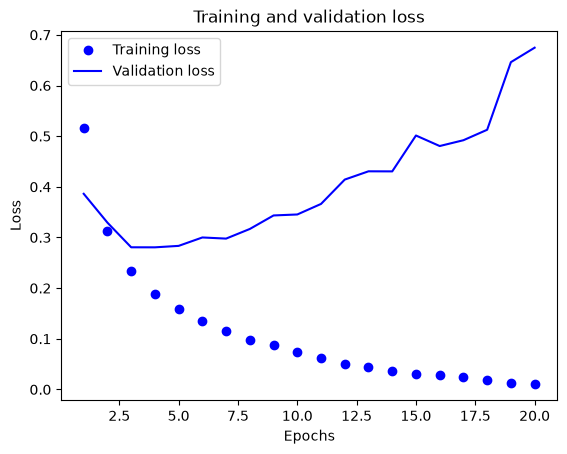

In [17]:
%pip install matplotlib

# Plotting the training and validation loss
import matplotlib.pyplot as plt
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

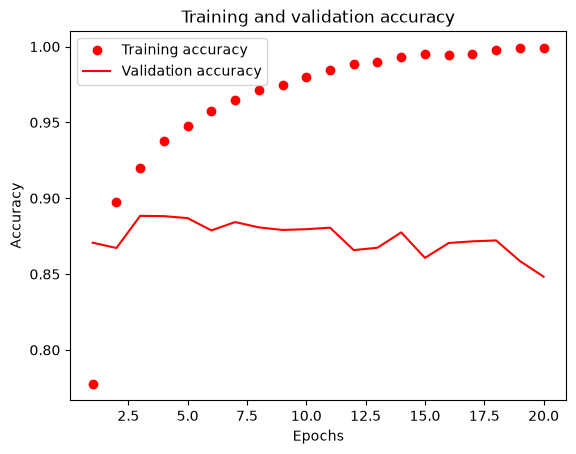

In [18]:
#Plot t ing the t raining and validat ion accuracy
accuracy_values = history_dict['accuracy']
val_accuracy_values = history_dict['val_accuracy']
epochs = range(1, len(accuracy_values) + 1)

plt.plot(epochs, accuracy_values, 'ro', label='Training accuracy')
plt.plot(epochs, val_accuracy_values, 'r', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [19]:
#re-train the model from scratch for four epochs
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',metrics=['accuracy'])
model.fit(potential_x_train, potential_y_train, epochs=4, batch_size=512)
results = model.evaluate(x_test, y_test)
results

Epoch 1/4
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7783 - loss: 0.5150 
Epoch 2/4
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9000 - loss: 0.3124
Epoch 3/4
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9253 - loss: 0.2318
Epoch 4/4
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9405 - loss: 0.1855
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8787 - loss: 0.2980


[0.29803740978240967, 0.8786799907684326]

In [20]:
model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 936us/step


array([[0.30480042],
       [0.99628055],
       [0.9673273 ],
       ...,
       [0.08522043],
       [0.1757187 ],
       [0.53732383]], shape=(25000, 1), dtype=float32)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7868 - loss: 0.4849 - val_accuracy: 0.8724 - val_loss: 0.3403
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8993 - loss: 0.2681 - val_accuracy: 0.8549 - val_loss: 0.3405
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9261 - loss: 0.1951 - val_accuracy: 0.8534 - val_loss: 0.3648
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9383 - loss: 0.1596 - val_accuracy: 0.8840 - val_loss: 0.3082
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9469 - loss: 0.1383 - val_accuracy: 0.8835 - val_loss: 0.3129
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9638 - loss: 0.1022 - val_accuracy: 0.8801 - val_loss: 0.3426
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9689 - loss: 0.0892 - val_accuracy: 0.8759 - val_loss: 0.3753
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9732 - loss: 0.0773 - val_accuracy: 0.8716 - val_los

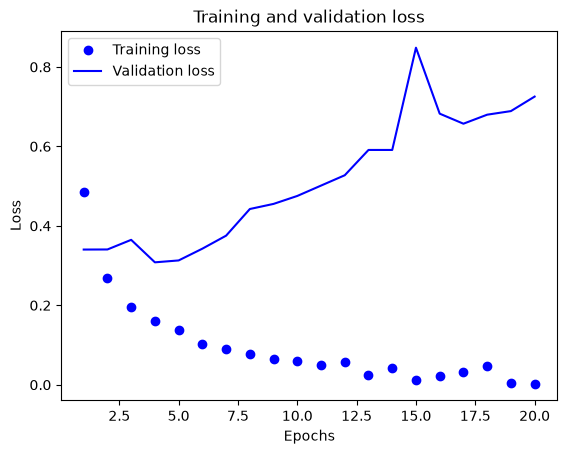

In [22]:
# Experiment -2

# use previously imported models and layers (from CELL INDEX: 8)
model = models.Sequential()
model.add(layers.Dense(32, activation='tanh', input_shape=(10000,)))
model.add(layers.Dense(32, activation='tanh'))
# single output for binary classification (matches y labels shape)
model.add(layers.Dense(1, activation='sigmoid'))

y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

from keras import optimizers
# use binary_crossentropy for binary labels
model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss='binary_crossentropy', metrics=['accuracy'])

# Rebuild the feature matrices in case earlier cells changed them
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

x_value = x_train[:10000]
y_value = y_train[:10000]

potential_x_train = x_train[10000:]
potential_y_train = y_train[10000:]

history = model.fit(
    potential_x_train,
    potential_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_value, y_value),
)

history_dict = history.history
history_dict.keys()

# Plotting the training and validation loss
import matplotlib.pyplot as plt
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()




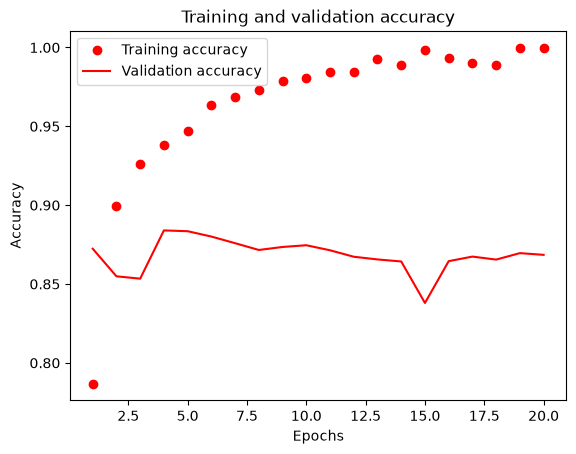

In [23]:
#Plot t ing the t raining and validat ion accuracy
accuracy_values = history_dict['accuracy']
val_accuracy_values = history_dict['val_accuracy']
epochs = range(1, len(accuracy_values) + 1)

plt.plot(epochs, accuracy_values, 'ro', label='Training accuracy')
plt.plot(epochs, val_accuracy_values, 'r', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [24]:
#re-train the model from scratch for four epochs
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',metrics=['accuracy'])
model.fit(potential_x_train, potential_y_train, epochs=4, batch_size=512)
results = model.evaluate(x_test, y_test)
results

Epoch 1/4
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7444 - loss: 0.5756 
Epoch 2/4
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8837 - loss: 0.3871
Epoch 3/4
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9082 - loss: 0.2899
Epoch 4/4
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9255 - loss: 0.2336
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8839 - loss: 0.2959


[0.2958792448043823, 0.8838800191879272]

In [ ]:
model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 954us/step


array([[0.32545328],
       [0.98626834],
       [0.8882767 ],
       ...,
       [0.11659667],
       [0.21153489],
       [0.5052657 ]], shape=(25000, 1), dtype=float32)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7872 - loss: 0.4737 - val_accuracy: 0.8740 - val_loss: 0.3172
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8904 - loss: 0.2735 - val_accuracy: 0.8513 - val_loss: 0.3593
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9200 - loss: 0.2065 - val_accuracy: 0.8828 - val_loss: 0.2874
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9391 - loss: 0.1629 - val_accuracy: 0.8783 - val_loss: 0.3146
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9451 - loss: 0.1427 - val_accuracy: 0.8825 - val_loss: 0.3240
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9603 - loss: 0.1091 - val_accuracy: 0.8738 - val_loss: 0.3913
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9581 - loss: 0.1140 - val_accuracy: 0.8760 - val_loss: 0.3796
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9721 - loss: 0.0860 - val_accuracy: 0.8754 - val_lo

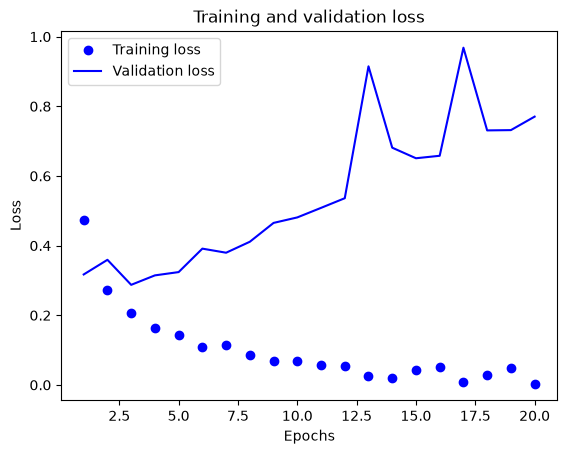

In [27]:
# Experiment -2

# use previously imported models and layers (from CELL INDEX: 8)
model = models.Sequential()
model.add(layers.Dense(64, activation='tanh', input_shape=(10000,)))
model.add(layers.Dense(64, activation='tanh'))
# single output for binary classification (matches y labels shape)
model.add(layers.Dense(1, activation='sigmoid'))

y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

from keras import optimizers
# use binary_crossentropy for binary labels
model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss='binary_crossentropy', metrics=['accuracy'])

# Rebuild the feature matrices in case earlier cells changed them
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

x_value = x_train[:10000]
y_value = y_train[:10000]

potential_x_train = x_train[10000:]
potential_y_train = y_train[10000:]

history = model.fit(
    potential_x_train,
    potential_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_value, y_value),
)

history_dict = history.history
history_dict.keys()

# Plotting the training and validation loss
import matplotlib.pyplot as plt
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()




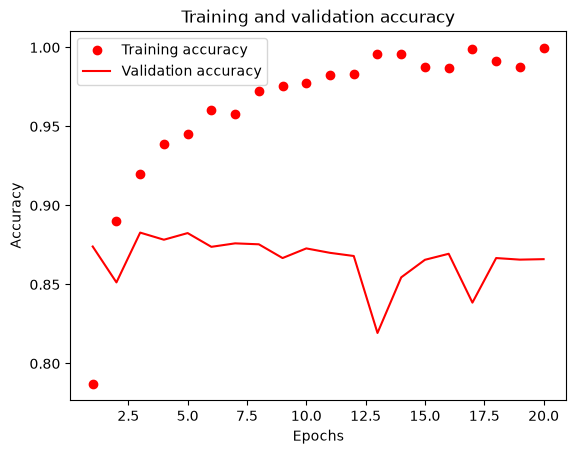

In [28]:
#Plot t ing the t raining and validat ion accuracy
accuracy_values = history_dict['accuracy']
val_accuracy_values = history_dict['val_accuracy']
epochs = range(1, len(accuracy_values) + 1)

plt.plot(epochs, accuracy_values, 'ro', label='Training accuracy')
plt.plot(epochs, val_accuracy_values, 'r', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [29]:
#re-train the model from scratch for four epochs
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',metrics=['accuracy'])
model.fit(potential_x_train, potential_y_train, epochs=4, batch_size=512)
results = model.evaluate(x_test, y_test)
results

Epoch 1/4
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7698 - loss: 0.5507 
Epoch 2/4
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8825 - loss: 0.3535
Epoch 3/4
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9129 - loss: 0.2630
Epoch 4/4
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9262 - loss: 0.2163
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8801 - loss: 0.2967


[0.29673507809638977, 0.8801199793815613]

In [30]:
model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


array([[0.32839888],
       [0.998405  ],
       [0.9475401 ],
       ...,
       [0.13439097],
       [0.23792705],
       [0.7019566 ]], shape=(25000, 1), dtype=float32)